In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os
import random
import shutil

BASE_DIR = Path("/content/drive/MyDrive/먼작귀/shelf_detection")

RAW_IMAGE_DIR = BASE_DIR / "outputs" / "shelf_images"
RAW_LABEL_DIR = BASE_DIR / "outputs" / "labels_shelf_lip"

OUT_DIR = BASE_DIR / "dataset" / "shelf_lip_yolo_seg"
IMAGE_OUT_DIR = OUT_DIR / "images"
LABEL_OUT_DIR = OUT_DIR / "labels"

RUNS_DIR = BASE_DIR / "runs"

RUN_NAME = "선반앞턱_yolov8_seg_v2_100_aug"

IMAGE_EXTS = [".jpg", ".jpeg", ".png"]

print("BASE_DIR:", BASE_DIR, BASE_DIR.exists())
print("RAW_IMAGE_DIR:", RAW_IMAGE_DIR, RAW_IMAGE_DIR.exists())
print("RAW_LABEL_DIR:", RAW_LABEL_DIR, RAW_LABEL_DIR.exists())
print("OUT_DIR:", OUT_DIR)
print("IMAGE_OUT_DIR:", IMAGE_OUT_DIR)
print("LABEL_OUT_DIR:", LABEL_OUT_DIR)
print("RUNS_DIR:", RUNS_DIR)
print("RUN_NAME:", RUN_NAME)

BASE_DIR: /content/drive/MyDrive/먼작귀/shelf_detection True
RAW_IMAGE_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/shelf_images True
RAW_LABEL_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/outputs/labels_yolo_seg True
OUT_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg
IMAGE_OUT_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/images
LABEL_OUT_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/labels
RUNS_DIR: /content/drive/MyDrive/먼작귀/shelf_detection/runs
RUN_NAME: 선반앞턱_yolov8_seg_v2_100_aug


In [ ]:
image_paths = sorted([
    p for p in RAW_IMAGE_DIR.iterdir()
    if p.suffix.lower() in IMAGE_EXTS
])

label_paths = sorted([
    p for p in RAW_LABEL_DIR.iterdir()
    if p.suffix.lower() == ".txt"
])

print("원본 이미지 개수:", len(image_paths))
print("원본 라벨 개수:", len(label_paths))

print("\n이미지 예시")
for p in image_paths[:10]:
    print(p.name)

print("\n라벨 예시")
for p in label_paths[:10]:
    print(p.name)

missing_labels = []
matched_pairs = []

for image_path in image_paths:
    label_path = RAW_LABEL_DIR / f"{image_path.stem}_shelf_lips.txt"
    if label_path.exists():
        matched_pairs.append((image_path, label_path))
    else:
        missing_labels.append(image_path.name)

print("\n매칭된 이미지-라벨 쌍:", len(matched_pairs))
print("라벨 없는 이미지:", len(missing_labels))

if missing_labels:
    print("\n라벨 없는 이미지 예시")
    for name in missing_labels[:20]:
        print(name)

원본 이미지 개수: 100
원본 라벨 개수: 105

이미지 예시
PhotoshopExtension_Image_1.jpeg
PhotoshopExtension_Image_10.jpeg
PhotoshopExtension_Image_11.jpeg
PhotoshopExtension_Image_12.jpeg
PhotoshopExtension_Image_13.jpeg
PhotoshopExtension_Image_14.jpeg
PhotoshopExtension_Image_15.jpeg
PhotoshopExtension_Image_16.jpeg
PhotoshopExtension_Image_17.jpeg
PhotoshopExtension_Image_18.jpeg

라벨 예시
PhotoshopExtension_Image_10_shelf_lips.txt
PhotoshopExtension_Image_11_shelf_lips.txt
PhotoshopExtension_Image_12_shelf_lips.txt
PhotoshopExtension_Image_13_shelf_lips.txt
PhotoshopExtension_Image_14_shelf_lips.txt
PhotoshopExtension_Image_15_shelf_lips.txt
PhotoshopExtension_Image_16_shelf_lips.txt
PhotoshopExtension_Image_17_shelf_lips.txt
PhotoshopExtension_Image_18_shelf_lips.txt
PhotoshopExtension_Image_19_shelf_lips.txt

매칭된 이미지-라벨 쌍: 100
라벨 없는 이미지: 0


In [ ]:
# 기존 학습용 데이터셋 폴더 삭제 후 재생성
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

for split in ["train", "val", "test"]:
    (IMAGE_OUT_DIR / split).mkdir(parents=True, exist_ok=True)
    (LABEL_OUT_DIR / split).mkdir(parents=True, exist_ok=True)

print("학습용 dataset 폴더 초기화 완료")

for split in ["train", "val", "test"]:
    print(split)
    print(" image dir:", (IMAGE_OUT_DIR / split).exists())
    print(" label dir:", (LABEL_OUT_DIR / split).exists())

학습용 dataset 폴더 초기화 완료
train
 image dir: True
 label dir: True
val
 image dir: True
 label dir: True
test
 image dir: True
 label dir: True


In [ ]:
def fix_yolo_seg_label(src_label_path, dst_label_path):
    """
    기존 YOLO-seg txt를 읽어서 좌표를 0~1 사이로 보정하고 저장.

    YOLO segmentation 형식:
    class_id x1 y1 x2 y2 x3 y3 ...
    """
    fixed_lines = []

    with open(src_label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        # class_id + 최소 3개 점(x,y) = 1 + 6 = 7개 이상 필요
        if len(parts) < 7:
            continue

        class_id = parts[0]

        try:
            coords = list(map(float, parts[1:]))
        except ValueError:
            print("[경고] 좌표 변환 실패:", src_label_path.name)
            continue

        fixed_coords = []
        for v in coords:
            v = max(0.0, min(1.0, v))
            fixed_coords.append(f"{v:.6f}")

        fixed_lines.append(" ".join([class_id] + fixed_coords))

    with open(dst_label_path, "w", encoding="utf-8") as f:
        f.write("\n".join(fixed_lines))

In [ ]:
# train / val / test 분리 + 이미지/라벨 복사
image_paths = sorted([
    p for p in RAW_IMAGE_DIR.iterdir()
    if p.suffix.lower() in IMAGE_EXTS
])

paired_items = []

for image_path in image_paths:
    src_label_path = RAW_LABEL_DIR / f"{image_path.stem}_shelf_lips.txt"

    if src_label_path.exists():
        paired_items.append((image_path, src_label_path))
    else:
        print("[경고] 라벨 없음:", image_path.name)

print("\n사용 가능한 이미지-라벨 쌍:", len(paired_items))

random.seed(42)
random.shuffle(paired_items)

n = len(paired_items)

train_end = int(n * 0.8)
val_end = int(n * 0.9)

success_count = 0
empty_label_count = 0

for i, (image_path, src_label_path) in enumerate(paired_items):
    if i < train_end:
        split = "train"
    elif i < val_end:
        split = "val"
    else:
        split = "test"

    dst_image_path = IMAGE_OUT_DIR / split / image_path.name
    dst_label_path = LABEL_OUT_DIR / split / f"{image_path.stem}.txt"

    shutil.copy2(image_path, dst_image_path)
    fix_yolo_seg_label(src_label_path, dst_label_path)

    if dst_label_path.read_text(encoding="utf-8").strip() == "":
        print("[경고] 빈 라벨:", dst_label_path.name)
        empty_label_count += 1

    success_count += 1

print("\n복사 완료")
print("성공:", success_count)
print("빈 라벨:", empty_label_count)

print("\n분리 결과")
for split in ["train", "val", "test"]:
    img_count = len([
        p for p in (IMAGE_OUT_DIR / split).iterdir()
        if p.suffix.lower() in IMAGE_EXTS
    ])
    lbl_count = len(list((LABEL_OUT_DIR / split).glob("*.txt")))
    print(f"{split}: images={img_count}, labels={lbl_count}")


사용 가능한 이미지-라벨 쌍: 100

복사 완료
성공: 100
빈 라벨: 0

분리 결과
train: images=80, labels=80
val: images=10, labels=10
test: images=10, labels=10


In [ ]:
# data.yaml 생성
data_yaml = f"""
path: {OUT_DIR}
train: images/train
val: images/val
test: images/test

names:
  0: shelf_lip
"""

yaml_path = OUT_DIR / "data.yaml"
yaml_path.write_text(data_yaml.strip(), encoding="utf-8")

print("data.yaml 생성 완료")
print(yaml_path)
print("\n--- data.yaml 내용 ---")
print(yaml_path.read_text(encoding="utf-8"))

data.yaml 생성 완료
/content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/data.yaml

--- data.yaml 내용 ---
path: /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg
train: images/train
val: images/val
test: images/test

names:
  0: shelf_lip


In [ ]:
print("data.yaml 존재:", (OUT_DIR / "data.yaml").exists())

for split in ["train", "val", "test"]:
    image_dir = IMAGE_OUT_DIR / split
    label_dir = LABEL_OUT_DIR / split

    images = sorted([
        p for p in image_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])
    labels = sorted(label_dir.glob("*.txt"))

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    print(f"\n[{split}]")
    print("images:", len(images))
    print("labels:", len(labels))
    print("이미지만 있고 라벨 없음:", len(image_stems - label_stems))
    print("라벨만 있고 이미지 없음:", len(label_stems - image_stems))

    if len(image_stems - label_stems) > 0:
        print("예시:", list(image_stems - label_stems)[:5])

    if len(label_stems - image_stems) > 0:
        print("예시:", list(label_stems - image_stems)[:5])

data.yaml 존재: True

[train]
images: 80
labels: 80
이미지만 있고 라벨 없음: 0
라벨만 있고 이미지 없음: 0

[val]
images: 10
labels: 10
이미지만 있고 라벨 없음: 0
라벨만 있고 이미지 없음: 0

[test]
images: 10
labels: 10
이미지만 있고 라벨 없음: 0
라벨만 있고 이미지 없음: 0


/content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/images/train/PhotoshopExtension_Image_1.jpeg
/content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/labels/train/PhotoshopExtension_Image_1.txt


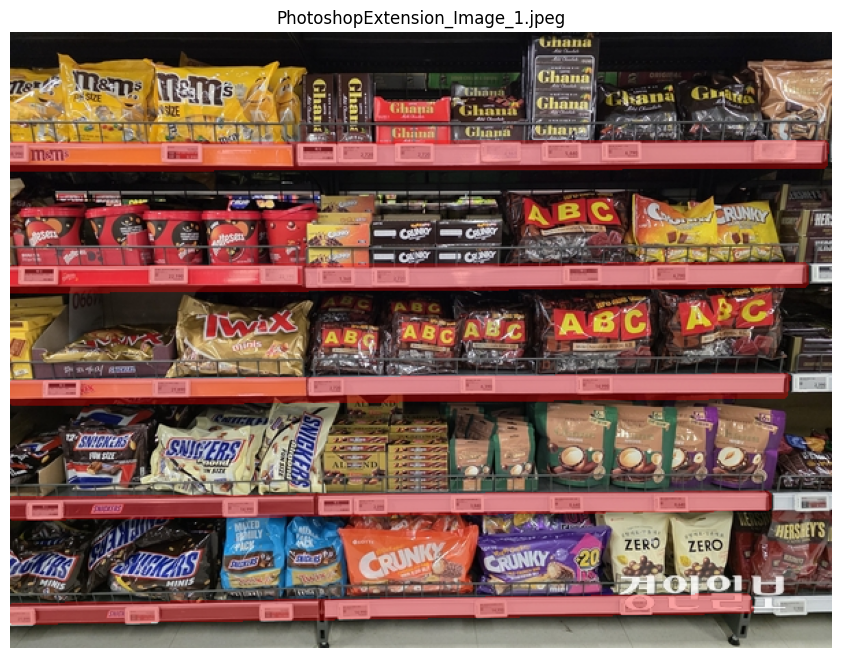

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def visualize_yolo_seg_label(image_path, label_path):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    overlay = image.copy()

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 7:
            continue

        coords = list(map(float, parts[1:]))
        pts = []

        for x_norm, y_norm in zip(coords[0::2], coords[1::2]):
            x = int(x_norm * w)
            y = int(y_norm * h)
            pts.append([x, y])

        pts = np.array(pts, dtype=np.int32)

        cv2.polylines(overlay, [pts], isClosed=True, color=(255, 0, 0), thickness=3)
        cv2.fillPoly(overlay, [pts], color=(255, 0, 0))

    blended = cv2.addWeighted(image, 0.65, overlay, 0.35, 0)

    plt.figure(figsize=(12, 8))
    plt.imshow(blended)
    plt.axis("off")
    plt.title(image_path.name)
    plt.show()


sample_image = sorted((IMAGE_OUT_DIR / "train").glob("*"))[0]
sample_label = LABEL_OUT_DIR / "train" / f"{sample_image.stem}.txt"

print(sample_image)
print(sample_label)

visualize_yolo_seg_label(sample_image, sample_label)

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.4 MB/s eta 0:00:00


In [ ]:
# # YOLOv8 segmentation 모델 학습
# from ultralytics import YOLO
# import torch

# print("CUDA 사용 가능:", torch.cuda.is_available())
# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))
# else:
#     print("현재 CPU로 실행 중입니다. 학습이 느릴 수 있어요.")

# model = YOLO("yolov8n-seg.pt")

# train_results = model.train(
#     data=str(OUT_DIR / "data.yaml"),
#     epochs=150,
#     imgsz=960,
#     batch=4,
#     patience=30,
#     project=str(RUNS_DIR),
#     name=RUN_NAME,
#     task="segment",
#     workers=2,
#     seed=42,
#     exist_ok=True,

#     # 데이터 증강 설정
#     hsv_h=0.01,          # 색상 변화 약하게
#     hsv_s=0.25,          # 채도 변화
#     hsv_v=0.25,          # 밝기 변화

#     degrees=3.0,         # 약한 회전
#     translate=0.05,      # 약한 이동
#     scale=0.20,          # 약한 확대/축소
#     shear=1.0,           # 약한 기울임
#     perspective=0.0005,  # 아주 약한 원근 변형

#     fliplr=0.5,          # 좌우 반전
#     flipud=0.0,          # 상하 반전 금지

#     mosaic=0.2,          # 너무 강하면 앞턱 형태가 깨져서 낮게
#     close_mosaic=15,

#     copy_paste=0.0,      # 앞턱 segmentation에는 일단 비추천
#     mixup=0.0,
#     erasing=0.0,         # 얇은 앞턱이 지워질 수 있어서 끔

#     cache=True
# )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA 사용 가능: True
GPU: Tesla T4
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/data.yaml, degrees=3.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscri

In [ ]:
# # YOLOv8 segmentation 모델 학습 - 데이터 증강 제거 버전
# from ultralytics import YOLO
# import torch
# from pathlib import Path

# print("CUDA 사용 가능:", torch.cuda.is_available())
# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))
# else:
#     print("현재 CPU로 실행 중입니다. 학습이 느릴 수 있어요.")

# # 기존 RUN_NAME과 구분되게 새 이름 사용
# RUN_NAME_NO_AUG = f"{RUN_NAME}_no_aug"

# # 혹시 이전 라벨/이미지 캐시가 남아있으면 삭제
# # 데이터셋을 다시 split했거나 라벨을 수정했으면 이거 해주는 게 안전함
# for cache_path in Path(OUT_DIR).rglob("*.cache"):
#     print("캐시 삭제:", cache_path)
#     cache_path.unlink()

# model = YOLO("yolov8n-seg.pt")

# train_results = model.train(
#     data=str(OUT_DIR / "data.yaml"),
#     epochs=150,
#     imgsz=960,
#     batch=4,
#     patience=30,
#     project=str(RUNS_DIR),
#     name=RUN_NAME_NO_AUG,
#     task="segment",
#     workers=2,
#     seed=42,
#     exist_ok=True,

#     # 색상/밝기 증강 제거
#     hsv_h=0.0,
#     hsv_s=0.0,
#     hsv_v=0.0,

#     # 기하학적 증강 제거
#     degrees=0.0,
#     translate=0.0,
#     scale=0.0,
#     shear=0.0,
#     perspective=0.0,

#     # 반전 제거
#     fliplr=0.0,
#     flipud=0.0,

#     # 복합 증강 제거
#     mosaic=0.0,
#     close_mosaic=0,
#     copy_paste=0.0,
#     mixup=0.0,

#     # 랜덤 지우기 제거
#     erasing=0.0,

#     # 이미지 캐시
#     cache=True
# )

CUDA 사용 가능: True
GPU: Tesla T4
캐시 삭제: /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/labels/train.cache
캐시 삭제: /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/labels/val.cache
캐시 삭제: /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/labels/test.cache
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=No

In [ ]:
# YOLOv8 segmentation 모델 학습 - 약한 증강 버전
from ultralytics import YOLO
import torch

print("CUDA 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("현재 CPU로 실행 중입니다. 학습이 느릴 수 있어요.")

RUN_NAME = "선반앞턱_yolov8s_seg_v4_weak_aug"

model = YOLO("yolov8s-seg.pt")

train_results = model.train(
    data=str(OUT_DIR / "data.yaml"),
    epochs=150,
    imgsz=960,
    batch=4,
    patience=30,

    project=str(RUNS_DIR),
    name=RUN_NAME,
    task="segment",
    workers=2,
    seed=42,
    exist_ok=True,

    # -----------------------------
    # 약한 색상/밝기 증강만 유지
    # -----------------------------
    hsv_h=0.005,     # 색상 변화 아주 약하게
    hsv_s=0.15,      # 채도 변화 약하게
    hsv_v=0.15,      # 밝기 변화 약하게

    # -----------------------------
    # 약한 위치/크기 변화만 유지
    # -----------------------------
    degrees=1.0,        # 거의 회전 안 함
    translate=0.03,     # 약한 이동
    scale=0.10,         # 약한 확대/축소
    shear=0.5,          # 약한 기울임
    perspective=0.0,    # 원근 변형 끔

    # -----------------------------
    # 앞턱 형태 깨질 수 있는 증강 제거
    # -----------------------------
    fliplr=0.0,         # 좌우 반전 끔
    flipud=0.0,         # 상하 반전 끔

    mosaic=0.0,         # mosaic 끔
    close_mosaic=0,

    copy_paste=0.0,
    mixup=0.0,
    erasing=0.0,

    cache=True
)

CUDA 사용 가능: True
GPU: Tesla T4
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/data.yaml, degrees=1.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.005, hsv_s=0.15, hsv_v=0.15, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=선반앞턱_yolov8s_seg_v

In [ ]:
best_model_path = Path(train_results.save_dir) / "weights" / "best.pt"

print("best_model_path:", best_model_path)
print("best.pt 존재:", best_model_path.exists())

best_model_path: /content/drive/.shortcut-targets-by-id/1qwubl3Zfy5buxG2NKhpBhCZdTiZ64Tx9/먼작귀/shelf_detection/runs/선반앞턱_yolov8s_seg_v4_weak_aug/weights/best.pt
best.pt 존재: True


In [ ]:
model = YOLO(str(best_model_path))

print("===== validation set 평가 =====")
val_metrics = model.val(
    data=str(OUT_DIR / "data.yaml"),
    imgsz=960,
    split="val"
)

print(val_metrics)

print("\n===== test set 평가 =====")
test_metrics = model.val(
    data=str(OUT_DIR / "data.yaml"),
    imgsz=960,
    split="test"
)

print(test_metrics)

===== validation set 평가 =====
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 233.1±123.8 MB/s, size: 821.0 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1qwubl3Zfy5buxG2NKhpBhCZdTiZ64Tx9/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/labels/val.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 3.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4s/it 1.4s
                   all         10         48      0.577       0.37      0.324      0.117      0.539      0.396      0.319      0.153
Speed: 3.0ms preprocess, 33.8ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/segment/val-8
ultralytics.utils.metrics.SegmentMetrics object with att

In [ ]:
model = YOLO(str(best_model_path))

results = model.predict(
    source=str(IMAGE_OUT_DIR / "test"),
    imgsz=960,
    conf=0.15,
    iou=0.5,
    save=True,
    project=str(RUNS_DIR),
    name=f"{RUN_NAME}_predict_test",
    exist_ok=True,
)


image 1/10 /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/images/test/PhotoshopExtension_Image_12.jpeg: 960x960 5 shelf_lips, 15.5ms
image 2/10 /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/images/test/PhotoshopExtension_Image_21.jpeg: 704x960 3 shelf_lips, 54.6ms
image 3/10 /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/images/test/PhotoshopExtension_Image_22.jpeg: 736x960 4 shelf_lips, 50.7ms
image 4/10 /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/images/test/PhotoshopExtension_Image_26.jpeg: 960x960 4 shelf_lips, 17.6ms
image 5/10 /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/images/test/PhotoshopExtension_Image_54.jpeg: 736x960 8 shelf_lips, 14.4ms
image 6/10 /content/drive/MyDrive/먼작귀/shelf_detection/dataset/shelf_lip_yolo_seg/images/test/PhotoshopExtension_Image_6.jpeg: 544x960 2 shelf_lips, 54.9ms
image 7/10 /content/drive/MyDrive/먼작귀/shelf_detection/dataset/sh

In [ ]:
# front line 추출
import numpy as np
import json

def polygon_to_front_line(points):
    """
    shelf_lip polygon에서 대표 front line을 생성.
    일단 좌측/우측 평균 y를 기준으로 선을 만듦.
    """
    pts = np.array(points, dtype=float)

    if len(pts) < 3:
        return None

    x_min = float(pts[:, 0].min())
    x_max = float(pts[:, 0].max())

    left_pts = pts[np.argsort(pts[:, 0])[:2]]
    right_pts = pts[np.argsort(pts[:, 0])[-2:]]

    left_y = float(left_pts[:, 1].mean())
    right_y = float(right_pts[:, 1].mean())

    return [[x_min, left_y], [x_max, right_y]]


def predict_shelf_lips(image_path, model, conf=0.15, imgsz=960):
    """
    이미지 1장에서 shelf_lip polygon과 front_line을 뽑는 함수.
    """
    results = model.predict(
        source=str(image_path),
        imgsz=imgsz,
        conf=conf,
        iou=0.5,
        save=False,
        verbose=False
    )

    result = results[0]

    shelf_lips = []

    if result.masks is None:
        return {
            "image_path": str(image_path),
            "shelf_lips": []
        }

    polygons = result.masks.xy

    for idx, poly in enumerate(polygons):
        points = poly.tolist()
        front_line = polygon_to_front_line(points)

        if front_line is None:
            continue

        avg_y = (front_line[0][1] + front_line[1][1]) / 2

        shelf_lips.append({
            "lip_id": idx,
            "polygon": points,
            "front_line": front_line,
            "avg_y": float(avg_y)
        })

    # 위에서 아래 순서로 정렬
    shelf_lips = sorted(shelf_lips, key=lambda x: x["avg_y"])

    # 정렬 후 row_id 부여
    for row_id, item in enumerate(shelf_lips):
        item["row_id"] = row_id

    return {
        "image_path": str(image_path),
        "shelf_lips": shelf_lips
    }


sample_test_image = sorted((IMAGE_OUT_DIR / "test").glob("*"))[0]

model = YOLO(str(best_model_path))
front_line_result = predict_shelf_lips(sample_test_image, model, conf=0.15, imgsz=960)

print("이미지:", sample_test_image.name)
print("탐지된 앞턱 개수:", len(front_line_result["shelf_lips"]))

for lip in front_line_result["shelf_lips"]:
    print("row_id:", lip["row_id"], "front_line:", lip["front_line"])

# JSON 저장
front_line_json_path = RUNS_DIR / "front_line_sample_result.json"
front_line_json_path.write_text(
    json.dumps(front_line_result, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("저장 완료:", front_line_json_path)

이미지: PhotoshopExtension_Image_12.jpeg
탐지된 앞턱 개수: 5
row_id: 0 front_line: [[538.6499633789062, 641.0249633789062], [1565.5499267578125, 244.12499237060547]]
row_id: 1 front_line: [[239.39999389648438, 1093.0499267578125], [2516.849853515625, 477.2249755859375]]
row_id: 2 front_line: [[522.8999633789062, 1455.2999267578125], [2479.0498046875, 1740.3749389648438]]
row_id: 3 front_line: [[535.5, 1795.4999389648438], [2334.14990234375, 2712.14990234375]]
row_id: 4 front_line: [[611.0999755859375, 2209.724853515625], [1521.449951171875, 2921.6248779296875]]
저장 완료: /content/drive/MyDrive/먼작귀/shelf_detection/runs/front_line_sample_result.json


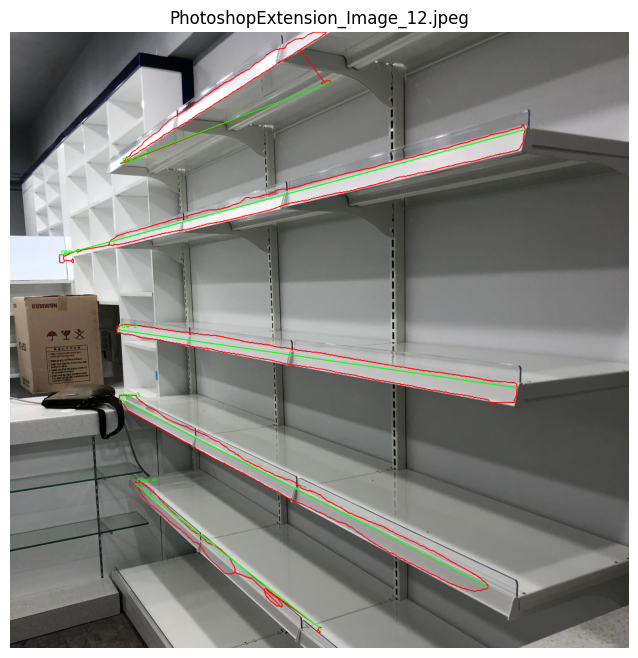

시각화 저장: /content/drive/MyDrive/먼작귀/shelf_detection/runs/front_line_sample_visualization.jpg


In [ ]:
# front line 시각화
import cv2
import matplotlib.pyplot as plt

def visualize_front_lines(image_path, front_line_result, save_path=None):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    vis = image.copy()

    for lip in front_line_result["shelf_lips"]:
        polygon = np.array(lip["polygon"], dtype=np.int32)
        front_line = lip["front_line"]
        row_id = lip["row_id"]

        # polygon 그리기
        cv2.polylines(vis, [polygon], isClosed=True, color=(255, 0, 0), thickness=3)

        # front line 그리기
        p1 = tuple(map(int, front_line[0]))
        p2 = tuple(map(int, front_line[1]))
        cv2.line(vis, p1, p2, color=(0, 255, 0), thickness=4)

        # row id 표시
        text_pos = (p1[0] + 10, p1[1] - 10)
        cv2.putText(
            vis,
            f"row {row_id}",
            text_pos,
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

    plt.figure(figsize=(12, 8))
    plt.imshow(vis)
    plt.axis("off")
    plt.title(image_path.name)
    plt.show()

    if save_path is not None:
        save_bgr = cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(save_path), save_bgr)
        print("시각화 저장:", save_path)


front_line_vis_path = RUNS_DIR / "front_line_sample_visualization.jpg"

visualize_front_lines(
    sample_test_image,
    front_line_result,
    save_path=front_line_vis_path
)